In [4]:
# Import Packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

In [5]:
#Import csv files as DataFrames
Data = pd.read_csv("Data.csv")
item = pd.read_csv("item.csv")
user = pd.read_csv("user.csv")

Data_df = pd.DataFrame(Data)
item_df = pd.DataFrame(item)
user_df = pd.DataFrame(user)

### EDA

In [6]:
# Data df

In [7]:
Data_df.shape

(100000, 4)

In [8]:
Data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user id    100000 non-null  int64
 1   movie id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [9]:
print(Data_df.describe())

            user id       movie id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08


In [10]:
Data_df.isnull().sum()

user id      0
movie id     0
rating       0
timestamp    0
dtype: int64

In [11]:
## Zero null values in the data
Data_df.isnull().sum().sum()

0

In [12]:
## item df

In [13]:
item_df.shape

(1681, 22)

In [14]:
item_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1681 entries, 0 to 1680
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie id      1681 non-null   int64 
 1   movie title   1681 non-null   object
 2   release date  1681 non-null   object
 3   unknown       1681 non-null   int64 
 4   Action        1681 non-null   int64 
 5   Adventure     1681 non-null   int64 
 6   Animation     1681 non-null   int64 
 7   Childrens     1681 non-null   int64 
 8   Comedy        1681 non-null   int64 
 9   Crime         1681 non-null   int64 
 10  Documentary   1681 non-null   int64 
 11  Drama         1681 non-null   int64 
 12  Fantasy       1681 non-null   int64 
 13  Film-Noir     1681 non-null   int64 
 14  Horror        1681 non-null   int64 
 15  Musical       1681 non-null   int64 
 16  Mystery       1681 non-null   int64 
 17  Romance       1681 non-null   int64 
 18  Sci-Fi        1681 non-null   int64 
 19  Thrill

In [15]:
print(item_df.describe())

          movie id      unknown       Action    Adventure    Animation  \
count  1681.000000  1681.000000  1681.000000  1681.000000  1681.000000   
mean    841.841761     0.000595     0.149316     0.080309     0.024985   
std     485.638077     0.024390     0.356506     0.271852     0.156126   
min       1.000000     0.000000     0.000000     0.000000     0.000000   
25%     422.000000     0.000000     0.000000     0.000000     0.000000   
50%     842.000000     0.000000     0.000000     0.000000     0.000000   
75%    1262.000000     0.000000     0.000000     0.000000     0.000000   
max    1682.000000     1.000000     1.000000     1.000000     1.000000   

         Childrens       Comedy        Crime  Documentary        Drama  \
count  1681.000000  1681.000000  1681.000000  1681.000000  1681.000000   
mean      0.072576     0.300416     0.064842     0.029744     0.431291   
std       0.259516     0.458576     0.246321     0.169931     0.495404   
min       0.000000     0.000000     0

In [16]:
## Zero null values in the data
item_df.isnull().sum().sum()

0

In [17]:
## user df

In [18]:
user_df.shape

(943, 5)

In [19]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user id     943 non-null    int64 
 1   age         943 non-null    int64 
 2   gender      943 non-null    object
 3   occupation  943 non-null    object
 4   zip code    943 non-null    object
dtypes: int64(2), object(3)
memory usage: 37.0+ KB


In [20]:
print(user_df.describe())

          user id         age
count  943.000000  943.000000
mean   472.000000   34.051962
std    272.364951   12.192740
min      1.000000    7.000000
25%    236.500000   25.000000
50%    472.000000   31.000000
75%    707.500000   43.000000
max    943.000000   73.000000


In [21]:
## Zero null values in the data
user_df.isnull().sum().sum()

0

**Observations:**

1) Judging by the contents of the head and tail ends of the dataframes, there does not yet apear to be any null, garbage, or missing values. A more in-depth analysis of the data is needed to determine that.

2) Some of these dataframes are very large. So, more in-depth analysis of the data is needed to determine the fidelity of the data.

3) So far, most columns appear to have continuous, numerical data, so running a function that looks for any categorical or non-continuous data in those columns would be good to possibly identify any garbage values. 

### Find the number of movies per genre using the item data

In [22]:
## Creating a new dataframe titled "item_genres_df", dropping all coluns containing categorical data.
item_genres_df = item_df.drop('movie title',axis=1)
item_genres_df.drop('release date',axis=1, inplace=True)
item_genres_df.drop('movie id',axis=1, inplace=True)

## Each column appears to contain boolean/binary data.
## So, the sum of each column of numerical data should give us the number of titles in each genre.
print(item_genres_df.sum())

unknown          1
Action         251
Adventure      135
Animation       42
Childrens      122
Comedy         505
Crime          109
Documentary     50
Drama          725
Fantasy         22
Film-Noir       24
Horror          92
Musical         56
Mystery         61
Romance        247
Sci-Fi         101
Thriller       251
War             71
Western         27
dtype: int64


**Insights:**
the above dataframe shows the sum of all titles of each genre.

In [23]:
## Finding the row where 'unknown' = 1
item_df.loc[item_df['unknown'] == 1]

,movie id,movie title,release date,unknown,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
1371,1373,Good Morning,4-Feb-1971,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
## Dropping the offending column
item_df.drop(1371, axis=0, inplace=True)

In [25]:
## The row for the title "Good Morning" no longer exists.
item_df.loc[item_df['unknown'] == 1]

,movie id,movie title,release date,unknown,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western


In [26]:
## Verifying that there are no longer any 'True' values in column "unknown"
## This serves to verify that there are indeed no other remaining titles of unknown genre.
item_df['unknown'].sum()

0

In [27]:
## Good housekeeping, drop the column "unknown," since it is no longer needed.
item_df.drop('unknown', axis=1, inplace=True)

In [28]:
## As we can see, no more column titled "unknown"
item_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1680 entries, 0 to 1680
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie id      1680 non-null   int64 
 1   movie title   1680 non-null   object
 2   release date  1680 non-null   object
 3   Action        1680 non-null   int64 
 4   Adventure     1680 non-null   int64 
 5   Animation     1680 non-null   int64 
 6   Childrens     1680 non-null   int64 
 7   Comedy        1680 non-null   int64 
 8   Crime         1680 non-null   int64 
 9   Documentary   1680 non-null   int64 
 10  Drama         1680 non-null   int64 
 11  Fantasy       1680 non-null   int64 
 12  Film-Noir     1680 non-null   int64 
 13  Horror        1680 non-null   int64 
 14  Musical       1680 non-null   int64 
 15  Mystery       1680 non-null   int64 
 16  Romance       1680 non-null   int64 
 17  Sci-Fi        1680 non-null   int64 
 18  Thriller      1680 non-null   int64 
 19  War   

In [29]:
item_df.head()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story,01-Jan-1995,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye,01-Jan-1995,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms,01-Jan-1995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty,01-Jan-1995,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat,01-Jan-1995,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


### Finding titles under more than one genre

In [30]:
## Reusing "item_genres_df" from before, now updated from removing "unknown" genre column.
item_genres_df.head()

,unknown,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [31]:
## This should give us the number of genres of each item
item_genres_df.sum(axis=1)

0       3
1       3
2       1
3       3
4       3
       ..
1676    1
1677    2
1678    2
1679    1
1680    1
Length: 1681, dtype: int64

In [32]:
## Creating new empty data frame
item_multiple_genres_df = pd.DataFrame()

In [35]:
## Added necessary columns
item_multiple_genres_df['movie title'] = item_df['movie title']
item_multiple_genres_df['total genres'] = item_genres_df.sum(axis=1)

## Dataframe now shows total genres per title.
item_multiple_genres_df.tail()

,movie title,total genres
1676,Mat' i syn,1
1677,B. Monkey,2
1678,Sliding Doors,2
1679,You So Crazy,1
1680,Scream of Stone (Schrei aus Stein),1


In [36]:
## Here is a dataframe that only shows only titles categorized under more than 1 genre.
item_multiple_genres_df = item_multiple_genres_df[item_multiple_genres_df['total genres'] > 1]
item_multiple_genres_df.tail()

,movie title,total genres
1667,MURDER and murder,3
1668,Tainted,2
1671,Mirage,2
1677,B. Monkey,2
1678,Sliding Doors,2


**Insights:**
It was relatively easy to calculate the genres per title, and display only the titles with multiple genres.
The last 3 questions were very difficult to solve.

### Univariate Plots

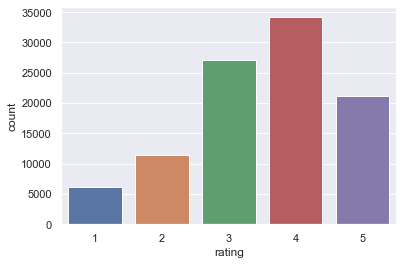

In [37]:
# Countplot for ratings
sns.countplot(Data_df['rating']);

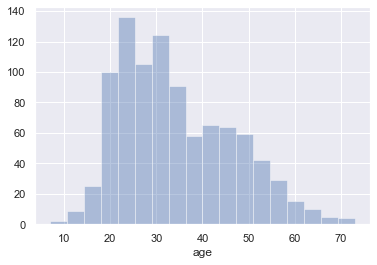

In [38]:
# Histogram for user ages
sns.distplot(user_df['age'], kde=False);

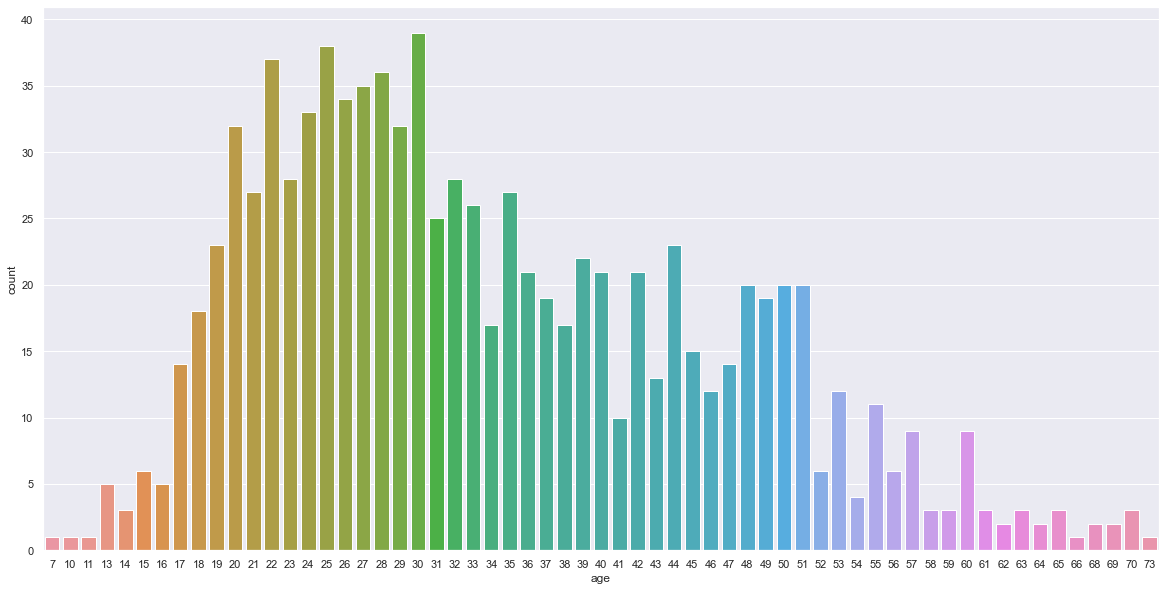

In [39]:
# Countplot for individual user ages
sns.set({'figure.figsize': (20,10)})
sns.countplot(user_df['age']);

In [40]:
# Release year
# Convert "release date" to datetime format
item_df['release date'] = pd.to_datetime(item_df['release date'])

In [42]:
item_df.tail()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
1676,1678,Mat' i syn,1998-02-06,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1677,1679,B. Monkey,1998-02-06,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1678,1680,Sliding Doors,1998-01-01,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1679,1681,You So Crazy,1994-01-01,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1680,1682,Scream of Stone (Schrei aus Stein),1996-03-08,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
## Extract year (.dt.year)
item_df['release date'].dt.year

0       1995
1       1995
2       1995
3       1995
4       1995
        ... 
1676    1998
1677    1998
1678    1998
1679    1994
1680    1996
Name: release date, Length: 1680, dtype: int64

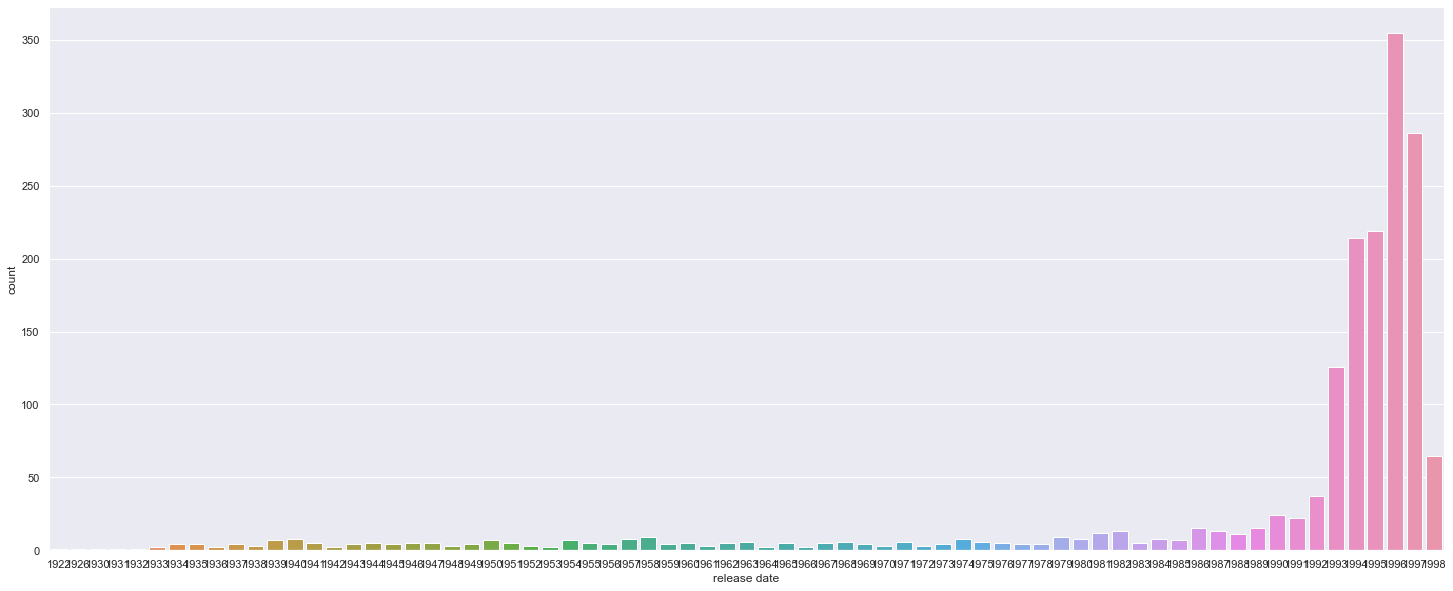

In [44]:
## Here is the plot. It's not really readible, but helps visualize the number of releases each year. 
sns.set({'figure.figsize': (25,10)})
sns.countplot(item_df['release date'].dt.year);

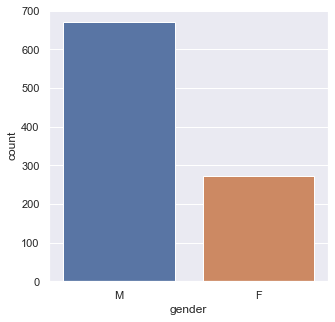

In [48]:
## Gender
sns.set({'figure.figsize': (5,5)})
sns.countplot(user_df['gender']);

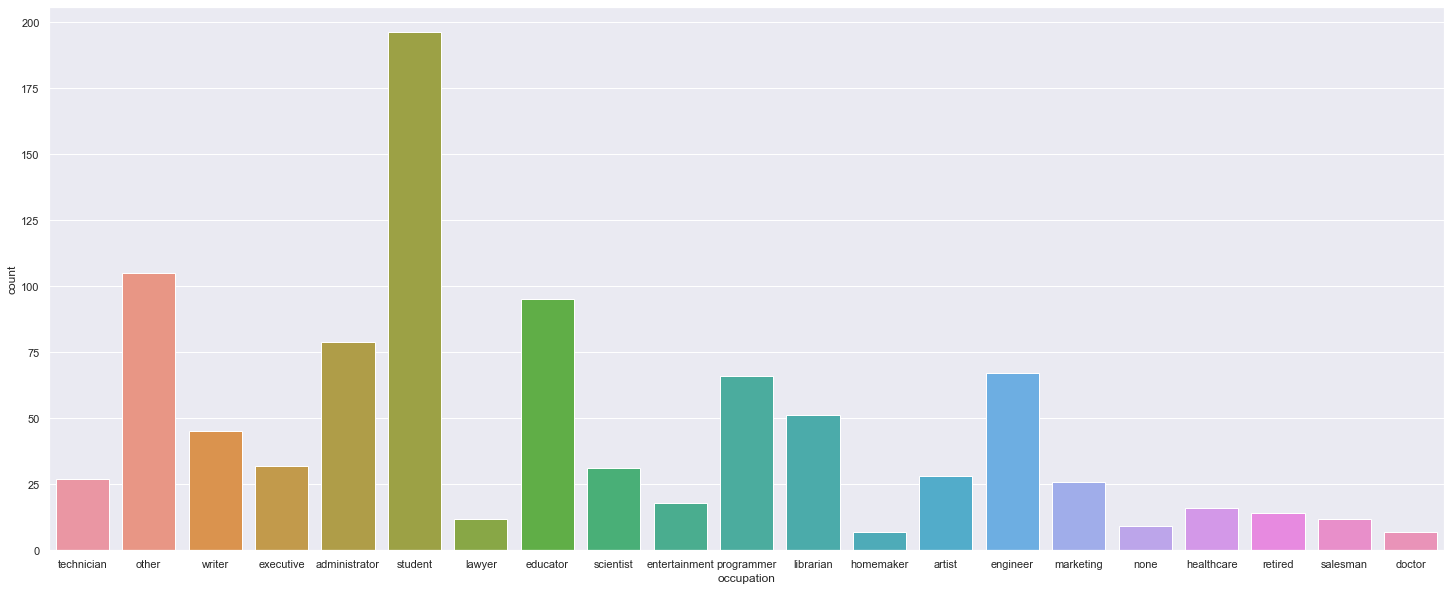

In [46]:
## Occupation
sns.set({'figure.figsize': (25,10)})
sns.countplot(user_df['occupation']);

### Visualize how the popularity of genres has changed over the years

I decided to use the **percent of number of releases in a year** as a parameter of popularity of a genre.

In [49]:
item_df.head()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story,1995-01-01,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye,1995-01-01,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms,1995-01-01,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty,1995-01-01,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat,1995-01-01,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [50]:
## Create table/df, percent of titles released in each genre per year
## Get count of movies of particular genre released in a particular year
## Groupby release year and genre
## Calculate percentage number of releases
## Create visualization as heatmap

In [51]:
pop_genre_change_df = item_df.copy()
pop_genre_change_df.head()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story,1995-01-01,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye,1995-01-01,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms,1995-01-01,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty,1995-01-01,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat,1995-01-01,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [54]:
## Must convert release year to dt format.
pop_genre_change_df['release date'] = pd.to_datetime(pop_genre_change_df['release date'])

In [55]:
## Adding "release year" column
pop_genre_change_df['release year'] = pop_genre_change_df['release date'].dt.year

In [56]:
pop_genre_change_df.drop('movie id', axis=1, inplace=True)
pop_genre_change_df.drop('movie title', axis=1, inplace=True)
pop_genre_change_df.drop('release date', axis=1, inplace=True)

In [57]:
pop_genre_change_df.tail()

,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,release year
1676,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1998
1677,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1998
1678,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1998
1679,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1994
1680,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1996


In [58]:
## Creating a copy of "pop_genre_change_df" to calculate "total" column.
total_df = pop_genre_change_df.copy()

## Dropping unnecessary columns.
## total_df.drop('release date',axis=1,inplace=True)
total_df.drop('release year',axis=1,inplace=True)
total_df.tail()

,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
1676,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1677,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0
1678,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
1679,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1680,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [59]:
total_df.sum(axis=1)

0       3
1       3
2       1
3       3
4       3
       ..
1676    1
1677    2
1678    2
1679    1
1680    1
Length: 1680, dtype: int64

In [60]:
## pop_genre_change_df['total releases'] = 1
## pop_genre_change_df

## This is how I got the total releases per genres/title column.
pop_genre_change_df['total releases'] = total_df.sum(axis=1)
pop_genre_change_df.tail()

,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,release year,total releases
1676,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1998,1
1677,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1998,2
1678,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1998,2
1679,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1994,1
1680,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1996,1


In [61]:
## Get sums of all titles and genres grouping by release year.
pop_genre_change_df.groupby(['release year']).sum().tail()

,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,total releases
release year,,,,,,,,,,,,,,,,,,,
1994,30,13,4,15,82,8,9,97,3,0,8,2,2,35,7,25,7,6,353
1995,40,22,6,21,63,11,5,89,3,1,14,3,5,37,15,39,5,2,381
1996,44,24,9,21,108,21,18,170,6,1,11,9,6,38,15,47,9,2,559
1997,46,20,3,22,87,30,6,113,4,2,8,5,18,51,13,54,14,0,496
1998,12,3,0,1,13,7,3,33,1,2,4,1,3,11,5,18,0,0,117


In [62]:
genre_percentages_df = pop_genre_change_df.groupby(['release year']).sum()

In [63]:
genre_percentages_df = genre_percentages_df.div(genre_percentages_df['total releases'], axis=0)*100

In [64]:
## Dropping 'total releases' column because it all shows up as a solid color on the heatmap, because it is at 100%
genre_percentages_df.drop('total releases', axis=1, inplace=True)

In [65]:
genre_percentages_df.tail()

,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
release year,,,,,,,,,,,,,,,,,,
1994,8.498584,3.682720,1.133144,4.249292,23.229462,2.266289,2.549575,27.478754,0.849858,0.000000,2.266289,0.566572,0.566572,9.915014,1.983003,7.082153,1.983003,1.699717
1995,10.498688,5.774278,1.574803,5.511811,16.535433,2.887139,1.312336,23.359580,0.787402,0.262467,3.674541,0.787402,1.312336,9.711286,3.937008,10.236220,1.312336,0.524934
1996,7.871199,4.293381,1.610018,3.756708,19.320215,3.756708,3.220036,30.411449,1.073345,0.178891,1.967800,1.610018,1.073345,6.797853,2.683363,8.407871,1.610018,0.357782
1997,9.274194,4.032258,0.604839,4.435484,17.540323,6.048387,1.209677,22.782258,0.806452,0.403226,1.612903,1.008065,3.629032,10.282258,2.620968,10.887097,2.822581,0.000000
1998,10.256410,2.564103,0.000000,0.854701,11.111111,5.982906,2.564103,28.205128,0.854701,1.709402,3.418803,0.854701,2.564103,9.401709,4.273504,15.384615,0.000000,0.000000


In [66]:
## The above resulting dataframe shows the percentage of genres of all releases each year.

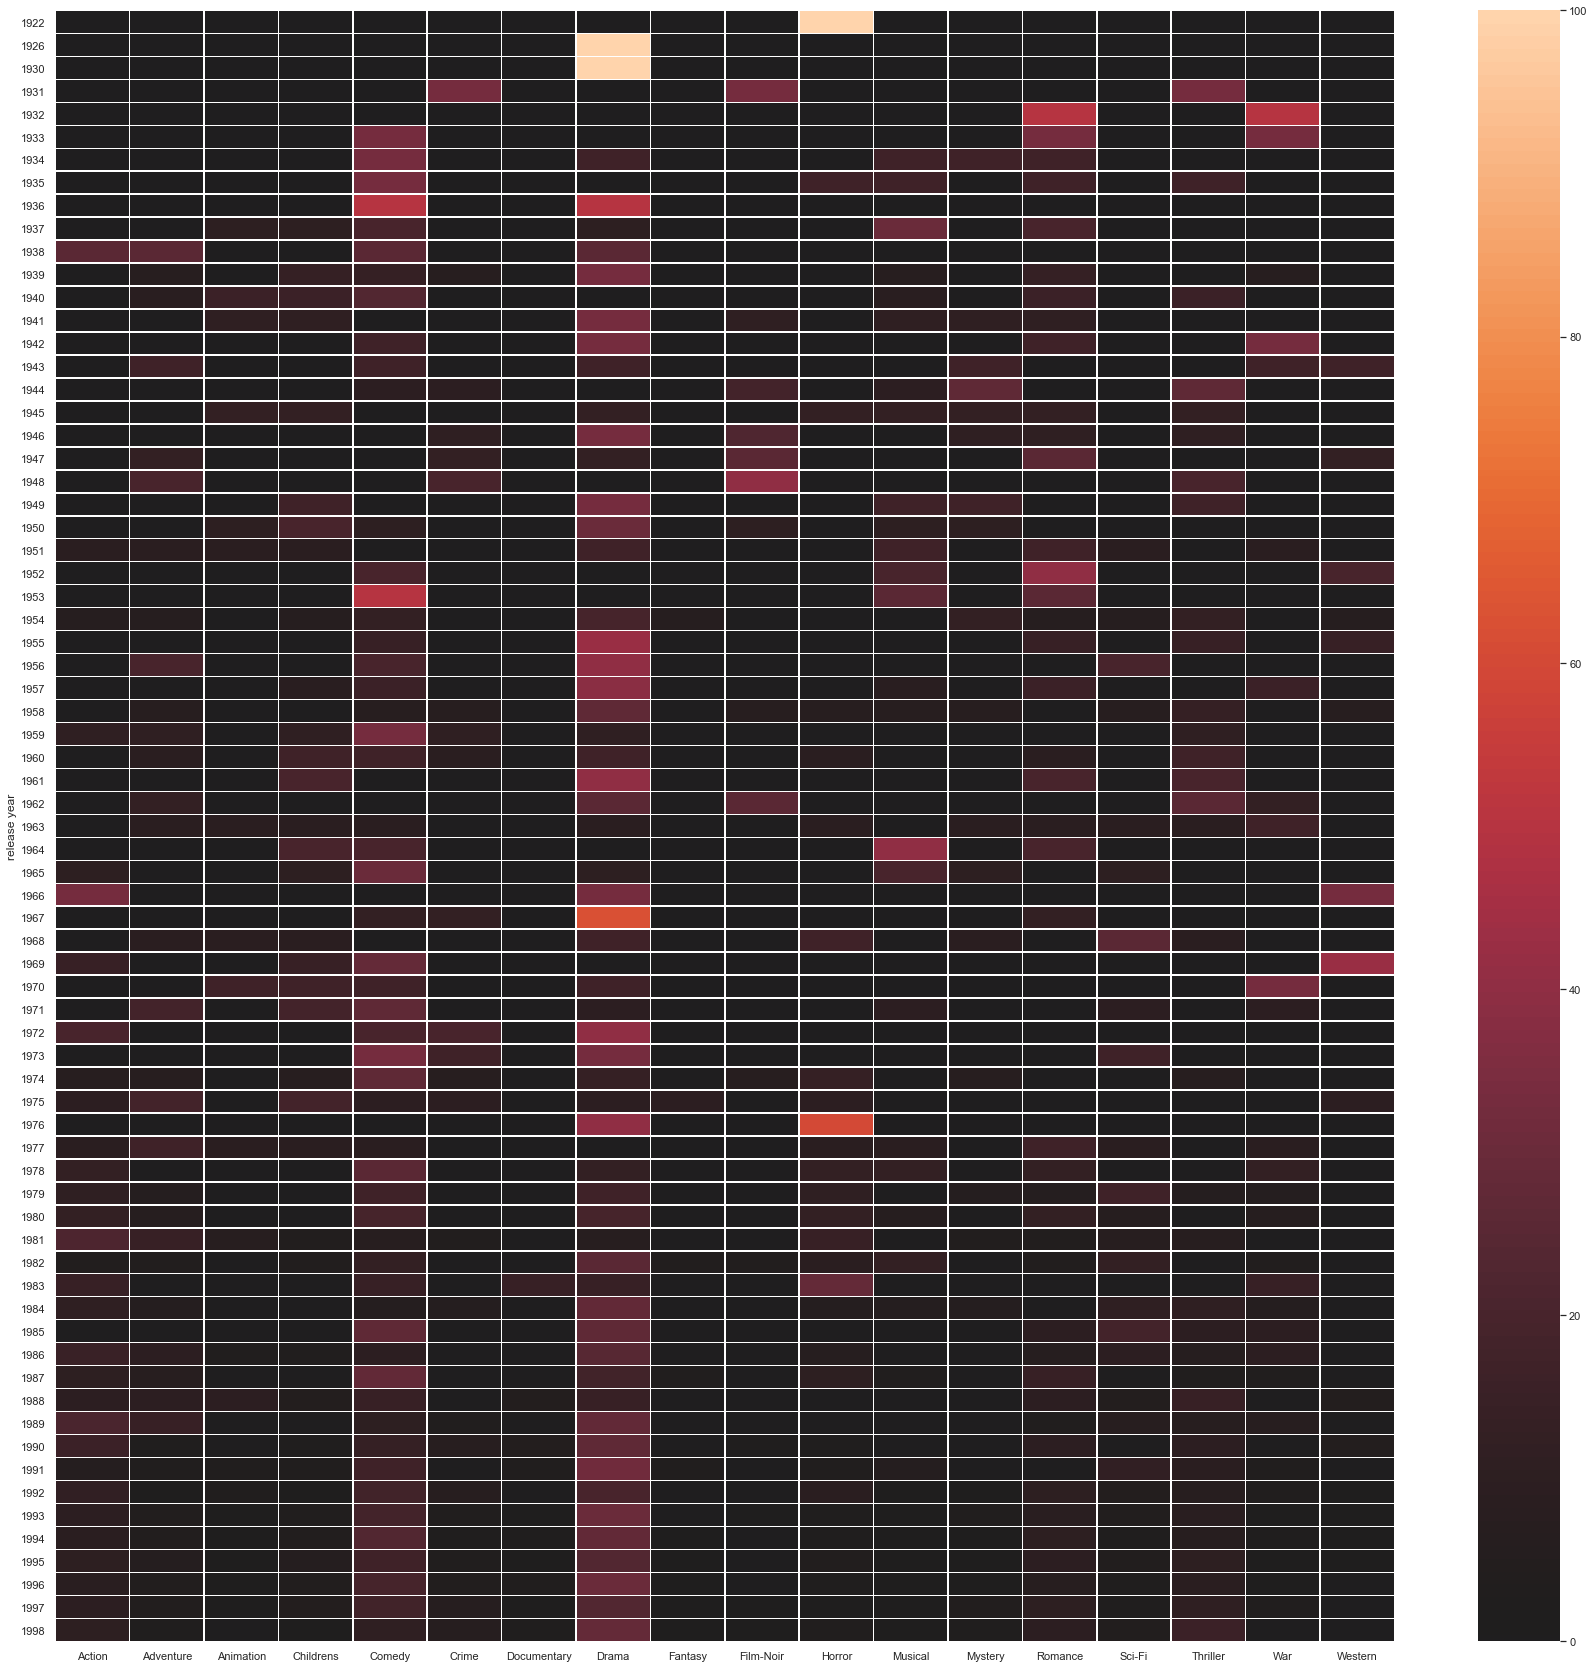

In [70]:
## Finally, it's time for a heatmap to visualize the popularity of genres over the years!
sns.set({'figure.figsize': (30,30)})
#sns.heatmap(genre_percentages_df, annot=False, linewidths=.5, fmt= '.1f', center = 1 );
sns.heatmap(genre_percentages_df, linewidths=.5, center = 1 );

**Insights:**

If I did the totals column by total releases (int of val 1 per row), as in total releases per year rather than total titles released by genre each year, then there would be more than 1 cel in each year/row at 100%, more than 2 at 50%, etc., which would be odd. 

This was the most intersting exercise in this whole project, **though a heatmap is perhaps not the best way to visualize the popularity of all of the genres over time, as it is too large and difficult to read. Instead, I will now try with univariate plots for each of the genre columns.**

### Find the top 25 movies in terms of average ratings for movies that have been rated more than 100 times

1. Find the count of ratings and average ratings for every movie.
2. Slice the movies which have ratings more than 100.
3. Sort values according to average rating such that movie which highest rating is on top.
4. Select top 25 movies.
5. Use the .merge() function to get the movie titles.

In [38]:
Data_df

,user id,movie id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [67]:
item_df

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story,01-Jan-1995,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye,01-Jan-1995,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms,01-Jan-1995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty,01-Jan-1995,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat,01-Jan-1995,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1676,1678,Mat' i syn,06-Feb-1998,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1677,1679,B. Monkey,06-Feb-1998,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1678,1680,Sliding Doors,01-Jan-1998,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1679,1681,You So Crazy,01-Jan-1994,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
## Both Data_df and item_df have column "movie id." 
## All merge operations will be performed on that column to get movie titles and other values.

In [68]:
## Merging item and Data dataframes.
item_data_df = pd.merge(Data_df, item_df, how='outer', on='movie id')

In [69]:
## Remove all unecessary columns
item_data_df.drop(['Action'], axis=1, inplace=True)
item_data_df.drop(['Adventure'], axis=1, inplace=True)
item_data_df.drop(['Animation'], axis=1, inplace=True)
item_data_df.drop(['Horror'], axis=1, inplace=True)
item_data_df.drop(['Musical'], axis=1, inplace=True)
item_data_df.drop(['Mystery'], axis=1, inplace=True)
item_data_df.drop(['Romance'], axis=1, inplace=True)
item_data_df.drop(['Sci-Fi'], axis=1, inplace=True)
item_data_df.drop(['Thriller'], axis=1, inplace=True)
item_data_df.drop(['War'], axis=1, inplace=True)
item_data_df.drop(['Western'], axis=1, inplace=True)
item_data_df.drop(['Childrens'], axis=1, inplace=True)
item_data_df.drop(['Comedy'], axis=1, inplace=True)
item_data_df.drop(['Crime'], axis=1, inplace=True)
item_data_df.drop(['Documentary'], axis=1, inplace=True)
item_data_df.drop(['Drama'], axis=1, inplace=True)
item_data_df.drop(['Fantasy'], axis=1, inplace=True)
item_data_df.drop(['Film-Noir'], axis=1, inplace=True)

In [70]:
item_data_df

,user id,movie id,rating,timestamp,movie title,release date
0,196,242,3,881250949,Kolya,24-Jan-1997
1,63,242,3,875747190,Kolya,24-Jan-1997
2,226,242,5,883888671,Kolya,24-Jan-1997
3,154,242,3,879138235,Kolya,24-Jan-1997
4,306,242,5,876503793,Kolya,24-Jan-1997
...,...,...,...,...,...,...
99995,840,1674,4,891211682,Mamma Roma,01-Jan-1962
99996,655,1640,3,888474646,"Eighth Day, The",01-Nov-1996
99997,655,1637,3,888984255,Girls Town,23-Aug-1996
99998,655,1630,3,887428735,"Silence of the Palace, The (Saimt el Qusur)",02-Feb-1996


In [71]:
## This is the table that all data will be pulled from here forward.

In [72]:
## Creating a column for "total ratings."
item_data_df['total ratings'] = 1
item_data_df

,user id,movie id,rating,timestamp,movie title,release date,total ratings
0,196,242,3,881250949,Kolya,24-Jan-1997,1
1,63,242,3,875747190,Kolya,24-Jan-1997,1
2,226,242,5,883888671,Kolya,24-Jan-1997,1
3,154,242,3,879138235,Kolya,24-Jan-1997,1
4,306,242,5,876503793,Kolya,24-Jan-1997,1
...,...,...,...,...,...,...,...
99995,840,1674,4,891211682,Mamma Roma,01-Jan-1962,1
99996,655,1640,3,888474646,"Eighth Day, The",01-Nov-1996,1
99997,655,1637,3,888984255,Girls Town,23-Aug-1996,1
99998,655,1630,3,887428735,"Silence of the Palace, The (Saimt el Qusur)",02-Feb-1996,1


In [73]:
## Summing the total ratings by movie id to get the total number of ratings for each movie.
total_ratings = item_data_df.groupby(['movie id'])['total ratings'].sum()
total_ratings.to_frame()
total_ratings

movie id
1       452
2       131
3        90
4       209
5        86
       ... 
1678      1
1679      1
1680      1
1681      1
1682      1
Name: total ratings, Length: 1682, dtype: int64

In [74]:
## Getting the movies that were rated more than 100 times.
over100ratings = total_ratings[total_ratings > 100]
over100ratings

movie id
1       452
2       131
4       209
7       392
8       219
       ... 
926     101
928     104
1016    137
1028    148
1047    134
Name: total ratings, Length: 334, dtype: int64

In [75]:
## Getting the average rating for each movie.
average_ratings = item_data_df.groupby(['movie id'])['rating'].mean()
average_ratings

movie id
1       3.878319
2       3.206107
3       3.033333
4       3.550239
5       3.302326
          ...   
1678    1.000000
1679    3.000000
1680    2.000000
1681    3.000000
1682    3.000000
Name: rating, Length: 1682, dtype: float64

In [76]:
## Merging total ratings and average ratings into the same df.
top25_average_ratings = pd.merge(over100ratings, average_ratings, how='left', on='movie id')

## Changing name for readability
top25_average_ratings.rename(columns = {'rating':'average rating'}, inplace=True)
top25_average_ratings

,total ratings,average rating
movie id,,
1,452,3.878319
2,131,3.206107
4,209,3.550239
7,392,3.798469
8,219,3.995434
...,...,...
926,101,2.702970
928,104,3.115385
1016,137,3.459854


In [77]:
## Creating "movie titles" df using groupby to eliminate redundant records.
movie_titles = item_data_df.groupby(['movie id'])['movie title'].first()
movie_titles

movie id
1                                Toy Story 
2                                GoldenEye 
3                               Four Rooms 
4                               Get Shorty 
5                                  Copycat 
                       ...                 
1678                            Mat' i syn 
1679                             B. Monkey 
1680                         Sliding Doors 
1681                          You So Crazy 
1682    Scream of Stone (Schrei aus Stein) 
Name: movie title, Length: 1682, dtype: object

In [78]:
## Adding the movie titles to the df that will show the top 25 average ratings.
top25_average_ratings = pd.merge(top25_average_ratings, movie_titles, how='inner', on='movie id')
top25_average_ratings

,total ratings,average rating,movie title
movie id,,,
1,452,3.878319,Toy Story
2,131,3.206107,GoldenEye
4,209,3.550239,Get Shorty
7,392,3.798469,Twelve Monkeys
8,219,3.995434,Babe
...,...,...,...
926,101,2.702970,Down Periscope
928,104,3.115385,"Craft, The"
1016,137,3.459854,Con Air


In [79]:
## Sorting in descending order to get the top 25 film titles by average rating.
top25_average_ratings = top25_average_ratings.sort_values('average rating', ascending = False).head(25)
top25_average_ratings

,total ratings,average rating,movie title
movie id,,,
408,112,4.491071,"Close Shave, A"
318,298,4.466443,Schindler's List
169,118,4.466102,"Wrong Trousers, The"
483,243,4.456790,Casablanca
64,283,4.445230,"Shawshank Redemption, The"
603,209,4.387560,Rear Window
12,267,4.385768,"Usual Suspects, The"
50,583,4.358491,Star Wars
178,125,4.344000,12 Angry Men


In [3]:
Data_df.head()

,user id,movie id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
Data_df.shape

(100000, 4)

In [5]:
user_df.head()

,user id,age,gender,occupation,zip code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [6]:
user_df.shape

(943, 5)

In [81]:
item_df.head()

,movie id,movie title,release date,Action,Adventure,Animation,Childrens,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story,01-Jan-1995,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye,01-Jan-1995,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms,01-Jan-1995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty,01-Jan-1995,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat,01-Jan-1995,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [82]:
item_df.shape

(1680, 21)

In [9]:
## Merge all 3 tables together to look at coorelations between gender and genre.

In [83]:
## First, merge on movie id
combined_tables = pd.merge(Data_df, item_df, how='outer', on='movie id')
combined_tables

,user id,movie id,rating,timestamp,movie title,release date,Action,Adventure,Animation,Childrens,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya,24-Jan-1997,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,63,242,3,875747190,Kolya,24-Jan-1997,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,226,242,5,883888671,Kolya,24-Jan-1997,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,154,242,3,879138235,Kolya,24-Jan-1997,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,306,242,5,876503793,Kolya,24-Jan-1997,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,840,1674,4,891211682,Mamma Roma,01-Jan-1962,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99996,655,1640,3,888474646,"Eighth Day, The",01-Nov-1996,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99997,655,1637,3,888984255,Girls Town,23-Aug-1996,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99998,655,1630,3,887428735,"Silence of the Palace, The (Saimt el Qusur)",02-Feb-1996,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
combined_tables.isnull().values.any()

True

In [85]:
combined_tables.isnull().sum().sum()

200

In [86]:
combined_tables.isnull().sum()

user id          0
movie id         0
rating           0
timestamp        0
movie title     10
release date    10
Action          10
Adventure       10
Animation       10
Childrens       10
Comedy          10
Crime           10
Documentary     10
Drama           10
Fantasy         10
Film-Noir       10
Horror          10
Musical         10
Mystery         10
Romance         10
Sci-Fi          10
Thriller        10
War             10
Western         10
dtype: int64

In [87]:
## It seems that we want to avoid dropping columns whenever possible.
## I believe that the measure of central tendency best for replacing values is the mean or mode.
## However, most of the columns with missing data are either movie title, release date, or genre columns.
## So, because of the nature of these columns, I have decided to drop all rows with null values 
combined_tables.dropna(inplace=True)

In [88]:
combined_tables.isnull().sum()

user id         0
movie id        0
rating          0
timestamp       0
movie title     0
release date    0
Action          0
Adventure       0
Animation       0
Childrens       0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

In [89]:
## Then, merge on user id
combined_tables = pd.merge(combined_tables, user_df, how='outer', on='user id')
combined_tables

,user id,movie id,rating,timestamp,movie title,release date,Action,Adventure,Animation,Childrens,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,age,gender,occupation,zip code
0,196,242,3,881250949,Kolya,24-Jan-1997,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,49,M,writer,55105
1,196,257,2,881251577,Men in Black,04-Jul-1997,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,49,M,writer,55105
2,196,111,4,881251793,"Truth About Cats & Dogs, The",26-Apr-1996,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,49,M,writer,55105
3,196,25,4,881251955,"Birdcage, The",08-Mar-1996,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,49,M,writer,55105
4,196,382,4,881251843,"Adventures of Priscilla, Queen of the Desert, ...",01-Jan-1994,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,49,M,writer,55105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99985,873,313,5,891392177,Titanic,01-Jan-1997,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,48,F,administrator,33763
99986,873,326,4,891392656,G.I. Jane,01-Jan-1997,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,48,F,administrator,33763
99987,873,348,3,891392577,Desperate Measures,30-Jan-1998,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,48,F,administrator,33763
99988,873,358,2,891392698,Spawn,01-Aug-1997,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,48,F,administrator,33763


In [90]:
combined_tables.isnull().sum()

user id         0
movie id        0
rating          0
timestamp       0
movie title     0
release date    0
Action          0
Adventure       0
Animation       0
Childrens       0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
age             0
gender          0
occupation      0
zip code        0
dtype: int64

In [91]:
combined_tables.isnull().sum().sum()

0

In [92]:
## It seems that all 3 tables have been joined, and that there are no missing values.

In [93]:
combined_tables

,user id,movie id,rating,timestamp,movie title,release date,Action,Adventure,Animation,Childrens,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,age,gender,occupation,zip code
0,196,242,3,881250949,Kolya,24-Jan-1997,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,49,M,writer,55105
1,196,257,2,881251577,Men in Black,04-Jul-1997,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,49,M,writer,55105
2,196,111,4,881251793,"Truth About Cats & Dogs, The",26-Apr-1996,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,49,M,writer,55105
3,196,25,4,881251955,"Birdcage, The",08-Mar-1996,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,49,M,writer,55105
4,196,382,4,881251843,"Adventures of Priscilla, Queen of the Desert, ...",01-Jan-1994,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,49,M,writer,55105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99985,873,313,5,891392177,Titanic,01-Jan-1997,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,48,F,administrator,33763
99986,873,326,4,891392656,G.I. Jane,01-Jan-1997,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,48,F,administrator,33763
99987,873,348,3,891392577,Desperate Measures,30-Jan-1998,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,48,F,administrator,33763
99988,873,358,2,891392698,Spawn,01-Aug-1997,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,48,F,administrator,33763


In [95]:
## Shows total number of men and women in dataset.
combined_tables['gender'].value_counts()

M    74252
F    25738
Name: gender, dtype: int64

In [96]:
## Shows numbers of men and women who watch drama vs. those who do not.
combined_tables.groupby(['Drama'])['gender'].value_counts()

Drama  gender
0.0    M         45365
       F         14730
1.0    M         28887
       F         11008
Name: gender, dtype: int64

In [69]:
## Calculating the percentages.
per_male_drama = (28887/74253) * 100
per_male_drama

38.90347864732738

In [74]:
per_fem_drama = (11008/25738) * 100
per_fem_drama

42.76944595539669

In [77]:
print('Of men, ', round(per_male_drama, 1), '% watch Sci-Fi, and of women, ', round(per_fem_drama, 1), '% watch Sci-Fi.')
print("Therefore, the statement 'Men watch more drama than women' is false.")

Of men,  38.9 % watch Sci-Fi, and of women,  42.8 % watch Sci-Fi.
Therefore, the statement 'Men watch more drama than women' is false.


In [64]:
## Show total number of men and women who watch Sci-Fi vs. those that do not.
combined_tables.groupby(['Sci-Fi'])['gender'].value_counts()

Sci-Fi  gender
0.0     M         64152
        F         23109
1.0     M         10101
        F          2629
Name: gender, dtype: int64

In [60]:
## Calculating the percentages.
per_male_sci = (10101/74253) * 100
per_male_sci

13.603490768049776

In [55]:
per_fem_sci = (2629/25738) * 100
per_fem_sci

10.214468878700753

In [84]:
print('Of men, ', round(per_male_sci,1), '% watch Sci-Fi, and of women, ', round(per_fem_sci,1), '% watch Sci-Fi.')
print("Therefore, the statement 'Women watch more Sci-Fi than men,' is false")

Of men,  13.6 % watch Sci-Fi, and of women,  10.2 % watch Sci-Fi.
Therefore, the statement 'Women watch more Sci-Fi than men,' is false


In [79]:
## Shows numbers of men and women who watch romance vs. those who do not.
combined_tables.groupby(['Romance'])['gender'].value_counts()

Romance  gender
0.0      M         60650
         F         19880
1.0      M         13603
         F          5858
Name: gender, dtype: int64

In [80]:
## Calculating the percentages.
per_male_rom = (13603/74253) * 100
per_male_rom

18.319798526658857

In [81]:
per_fem_rom = (5858/25738) * 100
per_fem_rom

22.760121221540135

In [83]:
print('Of men, ', round(per_male_rom,1), '% watch romance, and of women, ', round(per_fem_rom,1), '% watch romance.')
print("Therefore, the statement 'Men watch more Romance than women,' is false")

Of men,  18.3 % watch romance, and of women,  22.8 % watch romance.
Therefore, the statement 'Men watch more Romance than women,' is false


**Conclusion:**
Indeed, as I have shown above, all 3 statements were false, but not by as much as one would think. 
It was very difficult for me to show the percentages in bar plots in some meaningful way. For some reason I thought I shouild do that even though it wasn't in the instructions. It was relatively simple to merge the datasets and calculate the percentages.

Is percentage a true way to measure which gender views a certain genre more than others? If you're looking for a measurement relative to eac gender as a whole, then I would think so. If you're wishing to measure by headcount, then I would think not. It seems we were measuring by percentage because there were far many more male reviews than female. So, calculating percentage would indeed be desirable becuase of this.
